# 01 — Exploratory Data Analysis

Understanding the raw transaction data before feature engineering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

%matplotlib inline

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from src.config import RAW_DATA_PATH, PROCESSED_DIR

df = pd.read_csv(RAW_DATA_PATH, parse_dates=["InvoiceDate"])
print(f"Shape: {df.shape}")
df.head()

Shape: (10000, 10)


,InvoiceID,CustomerID,InvoiceDate,ProductCategory,ProductID,Quantity,UnitPrice,DiscountPct,PaymentMethod,Returned
0,INV100000,C1362,2024-03-17 12:28:00,Grocery,P934,4,499,10,Cash,0
1,INV100001,C1842,2025-08-13 11:42:00,Books,P777,3,4999,30,NetBanking,0
2,INV100002,C1750,2024-04-06 07:21:00,Books,P945,5,2499,5,UPI,0
3,INV100003,C1241,2024-09-14 11:20:00,Sports,P514,5,199,10,Cash,1
4,INV100004,C1104,2024-11-09 15:24:00,Sports,P528,2,499,10,Card,0


## 1. Data Quality Checks

In [3]:
print('Missing values:')
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nUnique InvoiceIDs: {df['InvoiceID'].nunique()}")
print(f"Unique Customers: {df['CustomerID'].nunique()}")
print(f"Unique Products: {df['ProductID'].nunique()}")
df.info()

Missing values:
InvoiceID          0
CustomerID         0
InvoiceDate        0
ProductCategory    0
ProductID          0
Quantity           0
UnitPrice          0
DiscountPct        0
PaymentMethod      0
Returned           0
dtype: int64

Duplicate rows: 0

Unique InvoiceIDs: 10000
Unique Customers: 1000
Unique Products: 900
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   InvoiceID        10000 non-null  object        
 1   CustomerID       10000 non-null  object        
 2   InvoiceDate      10000 non-null  datetime64[ns]
 3   ProductCategory  10000 non-null  object        
 4   ProductID        10000 non-null  object        
 5   Quantity         10000 non-null  int64         
 6   UnitPrice        10000 non-null  int64         
 7   DiscountPct      10000 non-null  int64         
 8   PaymentMethod    10000 non-nu

## 2. Descriptive Statistics

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceID,10000,10000,INV100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerID,10000,1000,C1964,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InvoiceDate,10000,NaN,NaN,NaN,2025-01-01 18:38:32.286000128,2024-01-01 00:40:00,2024-07-04 01:45:00,2025-01-01 08:56:00,2025-07-04 11:14:00,2025-12-31 23:22:00,NaN
ProductCategory,10000,6,Sports,1708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductID,10000,900,P961,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,10000.0,NaN,NaN,NaN,2.9787,1.0,2.0,3.0,4.0,5.0,1.414301
UnitPrice,10000.0,NaN,NaN,NaN,1484.51,199.0,499.0,999.0,2499.0,4999.0,1505.28656
DiscountPct,10000.0,NaN,NaN,NaN,13.2455,0.0,5.0,10.0,20.0,30.0,9.870105
PaymentMethod,10000,5,Card,2034,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Returned,10000.0,NaN,NaN,NaN,0.1973,0.0,0.0,0.0,0.0,1.0,0.397981


## 3. Univariate Analysis

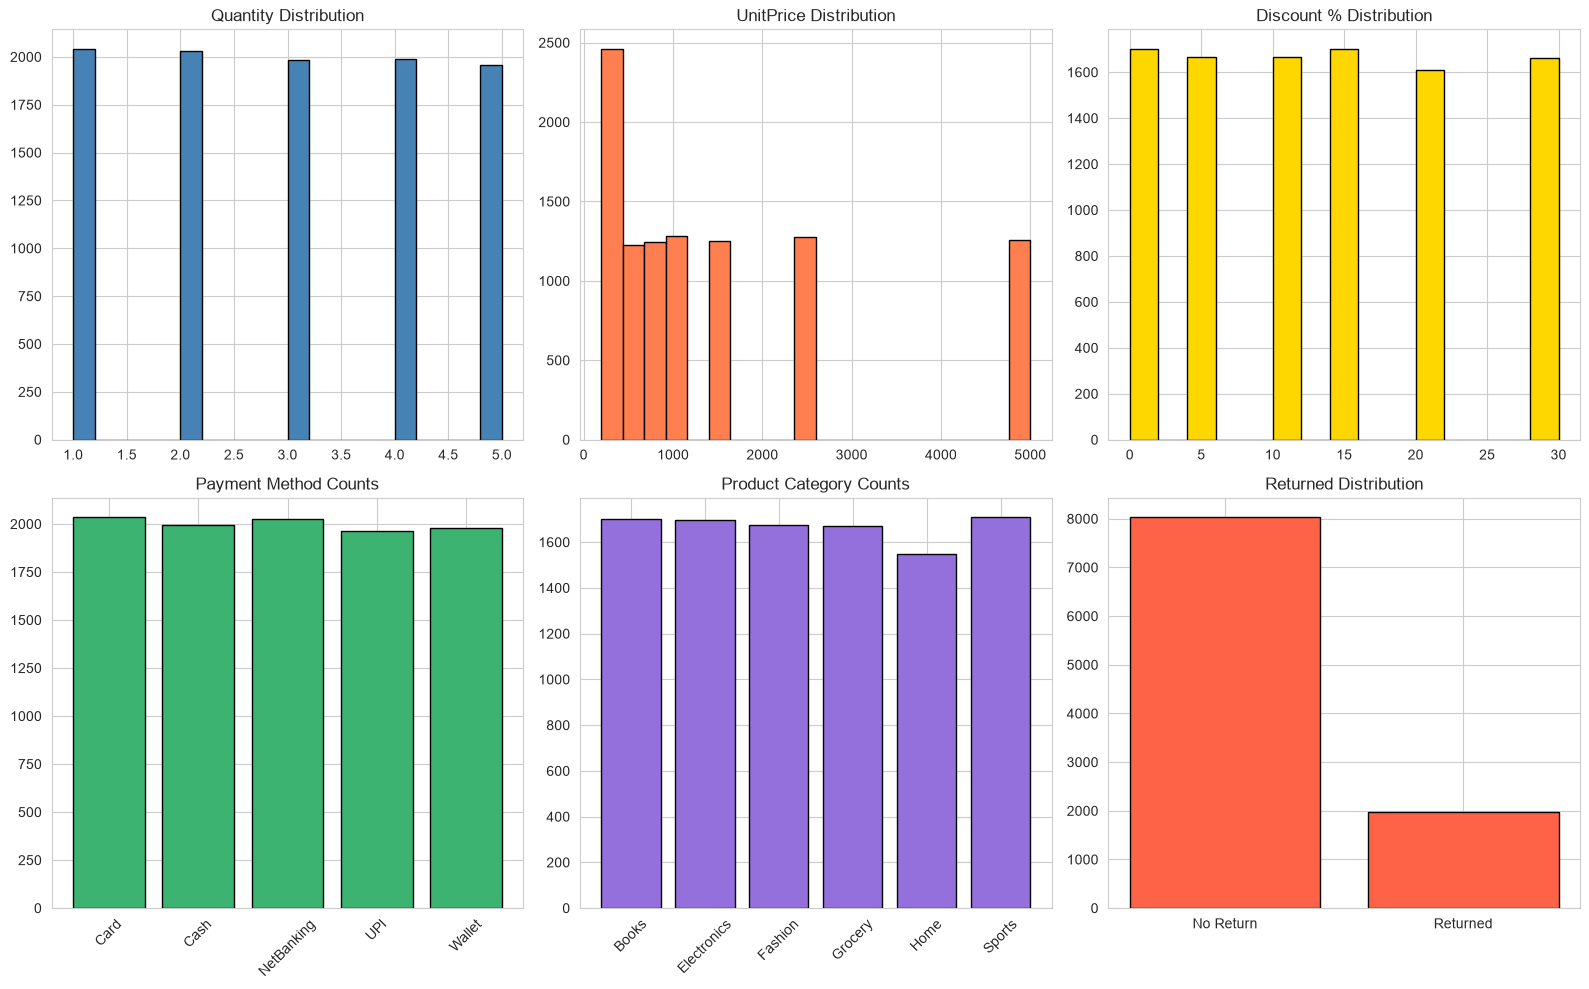

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].hist(df['Quantity'], bins=20, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Quantity Distribution')

axes[0, 1].hist(df['UnitPrice'], bins=20, color='coral', edgecolor='black')
axes[0, 1].set_title('UnitPrice Distribution')

axes[0, 2].hist(df['DiscountPct'], bins=15, color='gold', edgecolor='black')
axes[0, 2].set_title('Discount % Distribution')

axes[1, 0].bar(*np.unique(df['PaymentMethod'], return_counts=True), color='mediumseagreen', edgecolor='black')
axes[1, 0].set_title('Payment Method Counts')
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].bar(*np.unique(df['ProductCategory'], return_counts=True), color='mediumpurple', edgecolor='black')
axes[1, 1].set_title('Product Category Counts')
axes[1, 1].tick_params(axis='x', rotation=45)

axes[1, 2].bar(['No Return', 'Returned'], df['Returned'].value_counts().sort_index(), color='tomato', edgecolor='black')
axes[1, 2].set_title('Returned Distribution')

plt.tight_layout()
plt.show()

## 4. Customer-Level Aggregation

         TotalSales  OrderCount       AvgQty     AvgPrice
count   1000.000000  1000.00000  1000.000000  1000.000000
mean   14845.100000    10.00000     2.971396  1483.791266
std     6807.967751     3.14482     0.480701   512.537458
min     2493.000000     2.00000     1.200000   356.142857
25%     9789.750000     8.00000     2.666667  1109.833333
50%    14094.500000    10.00000     3.000000  1424.000000
75%    18881.750000    12.00000     3.285714  1820.250000
max    41278.000000    22.00000     4.714286  3327.571429


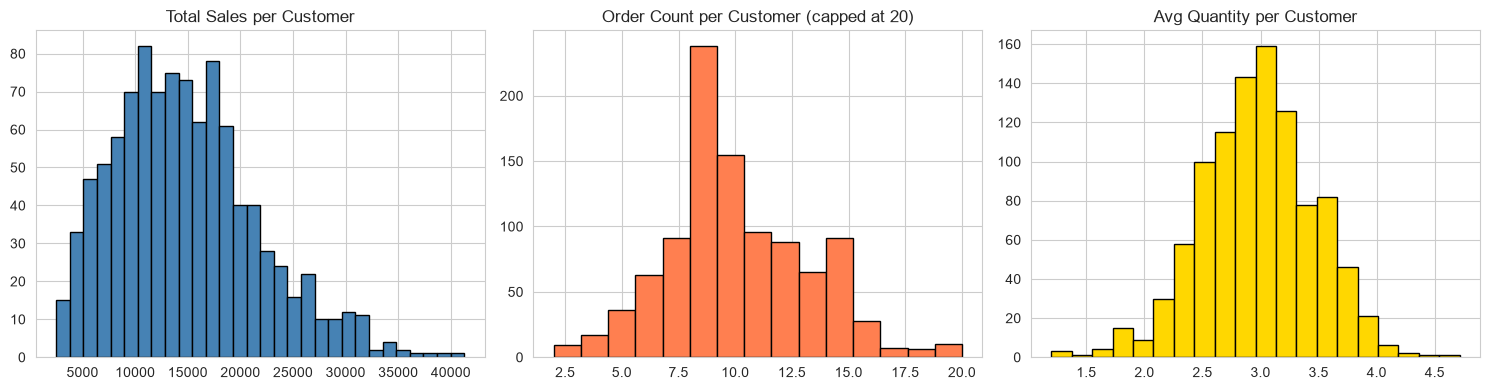

In [6]:
cust_agg = df.groupby('CustomerID').agg(
    TotalSales=('UnitPrice', 'sum'),
    OrderCount=('InvoiceID', 'nunique'),
    AvgQty=('Quantity', 'mean'),
    AvgPrice=('UnitPrice', 'mean'),
).reset_index()
print(cust_agg.describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(cust_agg['TotalSales'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Total Sales per Customer')
axes[1].hist(cust_agg['OrderCount'].clip(0, 20), bins=15, color='coral', edgecolor='black')
axes[1].set_title('Order Count per Customer (capped at 20)')
axes[2].hist(cust_agg['AvgQty'], bins=20, color='gold', edgecolor='black')
axes[2].set_title('Avg Quantity per Customer')
plt.tight_layout(); plt.show()

## 5. Correlation Heatmap

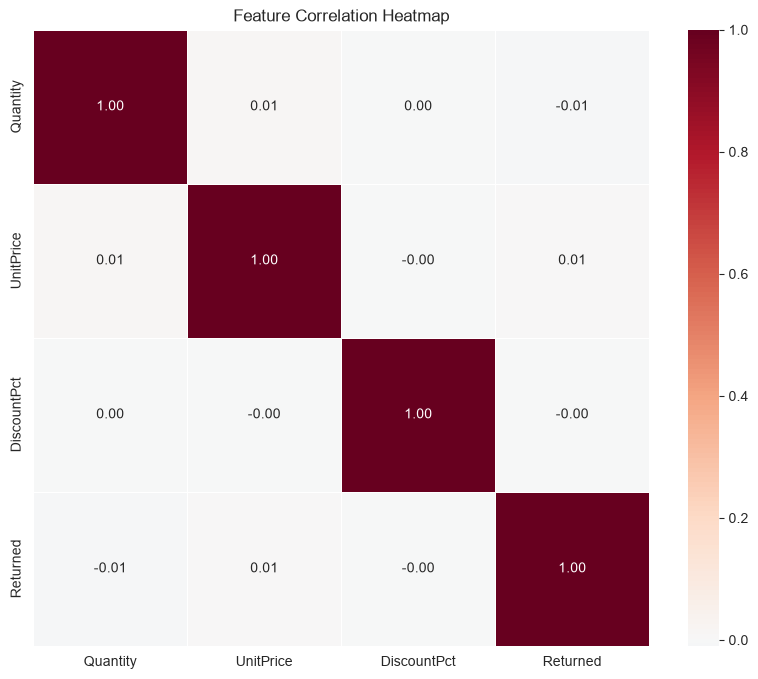

In [7]:
num_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

## 6. Outlier Analysis — Box Plots

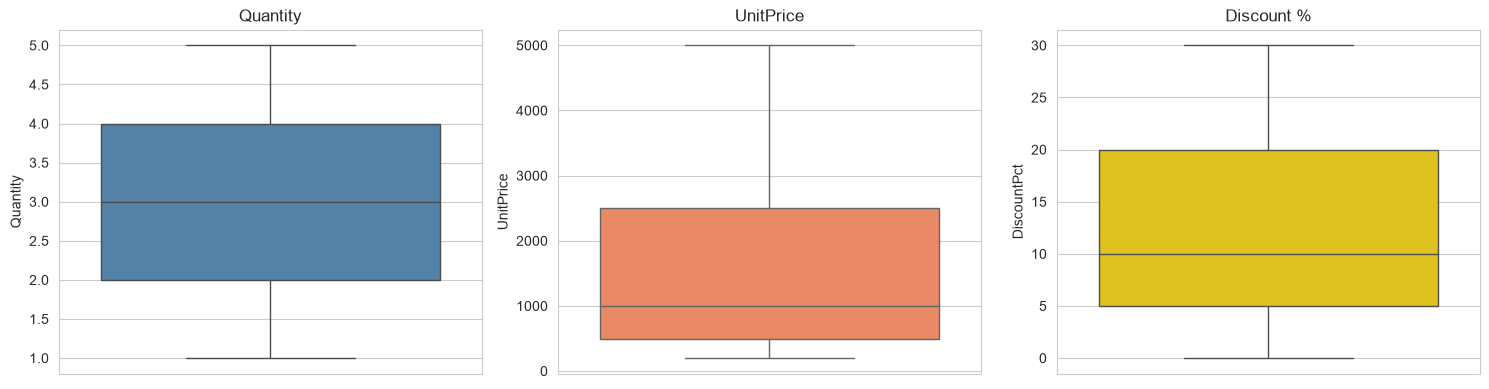

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=df['Quantity'], ax=axes[0], color='steelblue')
axes[0].set_title('Quantity')
sns.boxplot(y=df['UnitPrice'], ax=axes[1], color='coral')
axes[1].set_title('UnitPrice')
sns.boxplot(y=df['DiscountPct'], ax=axes[2], color='gold')
axes[2].set_title('Discount %')
plt.tight_layout(); plt.show()

## 7. Time Patterns — Day of Week & Hour

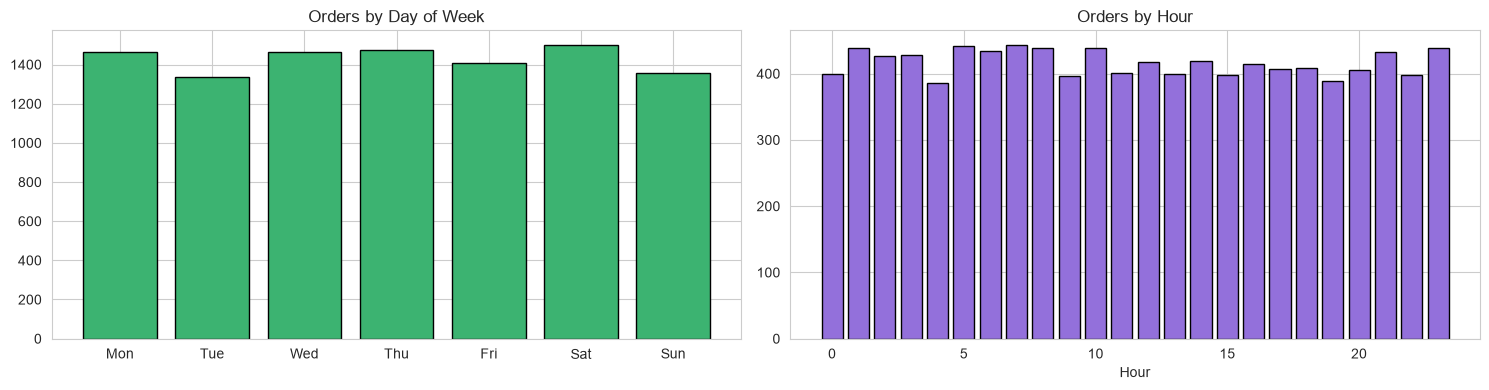

In [9]:
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['Hour'] = df['InvoiceDate'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_counts = df.groupby('DayOfWeek').size()
axes[0].bar(day_order, [day_counts.get(i,0) for i in range(7)], color='mediumseagreen', edgecolor='black')
axes[0].set_title('Orders by Day of Week')
hour_counts = df.groupby('Hour').size()
axes[1].bar(hour_counts.index, hour_counts.values, color='mediumpurple', edgecolor='black')
axes[1].set_title('Orders by Hour')
axes[1].set_xlabel('Hour')
plt.tight_layout(); plt.show()

## 8. Time Series — Sales Over Time

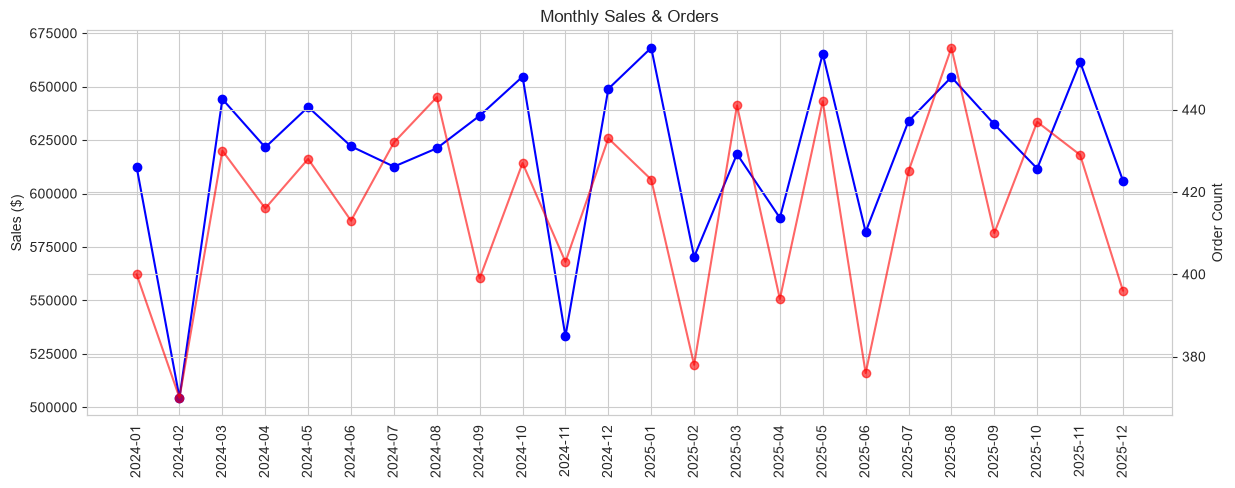

In [10]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby('Month').agg(Sales=('UnitPrice', 'sum'), Orders=('InvoiceID', 'nunique'))

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(monthly.index.astype(str), monthly['Sales'], 'bo-', label='Sales')
ax1.set_ylabel('Sales ($)')
ax1.tick_params(axis='x', rotation=90)
ax2 = ax1.twinx()
ax2.plot(monthly.index.astype(str), monthly['Orders'], 'ro-', alpha=0.6, label='Orders')
ax2.set_ylabel('Order Count')
plt.title('Monthly Sales & Orders')
plt.show()

## 9. Top Products & Categories

In [11]:
print('Top 10 Products by Sales:')
print(df.groupby('ProductID')['UnitPrice'].sum().sort_values(ascending=False).head(10))
print()
print('Sales by Category:')
print(df.groupby('ProductCategory')['UnitPrice'].sum().sort_values(ascending=False))

Top 10 Products by Sales:
ProductID
P993    43983
P853    42881
P751    42681
P651    42181
P174    40081
P261    39684
P915    39382
P359    38881
P539    38284
P417    37785
Name: UnitPrice, dtype: int64

Sales by Category:
ProductCategory
Electronics    2547505
Fashion        2530827
Sports         2517992
Grocery        2460128
Books          2420197
Home           2368451
Name: UnitPrice, dtype: int64


## 10. Missing & Anomaly Scan

In [12]:
print('Negative quantities:', (df['Quantity'] < 0).sum())
print('Zero quantities:', (df['Quantity'] == 0).sum())
print('Null CustomerIDs:', df['CustomerID'].isna().sum())
print('Invoices starting with C (cancelled):', df['InvoiceID'].astype(str).str.startswith('C').sum())

Negative quantities: 0
Zero quantities: 0
Null CustomerIDs: 0
Invoices starting with C (cancelled): 0


## 11. Key Takeaways

In [13]:
print('=== EDA TAKEAWAYS ===')
print(f'1. Dataset: {df.shape[0]} transactions, {df["CustomerID"].nunique()} customers')
print(f'2. Date range: {df["InvoiceDate"].min()} to {df["InvoiceDate"].max()}')
print(f'3. Missing values: {df.isnull().sum().sum()}')
print(f'4. Duplicates: {df.duplicated().sum()}')
print(f'5. Categories: {df["ProductCategory"].nunique()} product categories')
print(f'6. Payment methods: {df["PaymentMethod"].nunique()}')
print(f'7. Return rate: {df["Returned"].mean()*100:.1f}%')
print(f'8. Avg order value: ${df["UnitPrice"].mean():.2f}')

=== EDA TAKEAWAYS ===
1. Dataset: 10000 transactions, 1000 customers
2. Date range: 2024-01-01 00:40:00 to 2025-12-31 23:22:00
3. Missing values: 0
4. Duplicates: 0
5. Categories: 6 product categories
6. Payment methods: 5
7. Return rate: 19.7%
8. Avg order value: $1484.51
